# 🧠 Crisis Language Detection for Mental Health Risk Screening
**INFO 5368 | Cornell University**  
Mingyuan Pang, Shutian Fang, Kerui Bai, Katrina Wu, August Wang, Yingxuan Li

---
### Notebook Structure
1. Setup & Mount Google Drive
2. Load & Explore Data (EDA)
3. Preprocessing & TF-IDF Vectorization
4. Model 1: Logistic Regression (NumPy from scratch)
5. Model 2: Multinomial Naive Bayes (NumPy from scratch)
6. Evaluation & Comparison
7. Save Models for Streamlit

## 1. Setup

In [1]:
# Install dependencies
!pip install nltk scikit-learn matplotlib seaborn wordcloud -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score,
    precision_score, classification_report,
    roc_curve, confusion_matrix
)

print('✅ All imports successful')

✅ All imports successful


Download Dataset




In [3]:
!pip install gdown -q

import gdown
import pandas as pd

file_id = '1sXhsSwv9OqBga8jBhwrCY5rDzJ6AI6Pd'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'clean_data.csv'
gdown.download(url, output, quiet=False)


DATA_PATH = 'clean_data.csv'

Downloading...
From (original): https://drive.google.com/uc?id=1sXhsSwv9OqBga8jBhwrCY5rDzJ6AI6Pd
From (redirected): https://drive.google.com/uc?id=1sXhsSwv9OqBga8jBhwrCY5rDzJ6AI6Pd&confirm=t&uuid=b3a47754-48ff-4301-af43-1f024c2cf6e7
To: /content/clean_data.csv
100%|██████████| 249M/249M [00:06<00:00, 40.8MB/s]


## 2. Load Data & EDA

In [4]:

df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names: {df.columns.tolist()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(3)

Dataset shape: (231947, 4)

Column names: ['text', 'text_clean', 'label', 'label_binary']

Missing values:
text            0
text_clean      0
label           0
label_binary    0
dtype: int64


,text,text_clean,label,label_binary
0,Ex Wife Threatening SuicideRecently I left my ...,wife threaten suiciderec left wife good cheat ...,suicide,1
1,Am I weird I don't get affected by compliments...,weird dont get affect compliment come someon k...,non-suicide,0
2,Finally 2020 is almost over... So I can never ...,final almost never hear bad year ever swear fu...,non-suicide,0


Class distribution:
label
suicide        116021
non-suicide    115926
Name: count, dtype: int64

Balance ratio: 0.500 (0.5 = perfectly balanced)


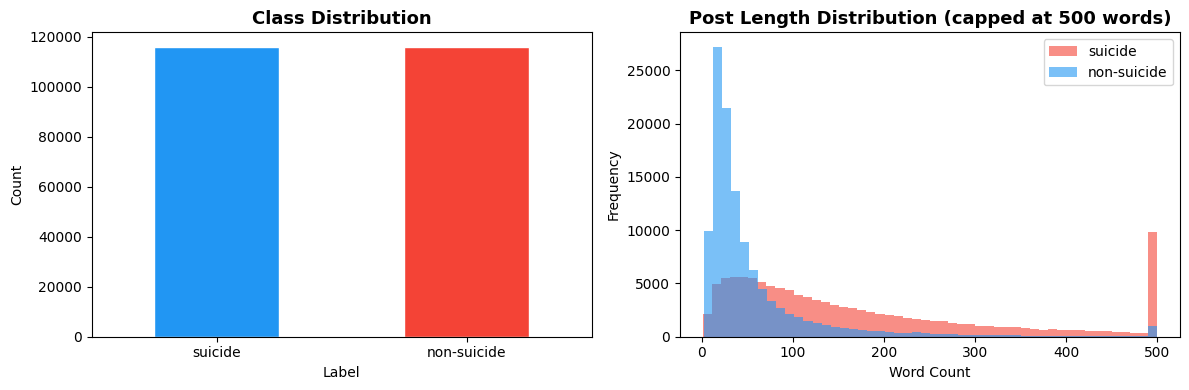


Mean word count — Suicide: 202.7
Mean word count — Non-suicide: 61.2


In [5]:
# Class distribution
print('Class distribution:')
print(df['label'].value_counts())
print(f'\nBalance ratio: {df["label_binary"].mean():.3f} (0.5 = perfectly balanced)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Post length distribution
df['word_count'] = df['text'].fillna('').apply(lambda x: len(x.split()))
for label, color in [('suicide', '#F44336'), ('non-suicide', '#2196F3')]:
    subset = df[df['label'] == label]['word_count']
    axes[1].hist(subset.clip(upper=500), bins=50, alpha=0.6, label=label, color=color)
axes[1].set_title('Post Length Distribution (capped at 500 words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean word count — Suicide: {df[df['label']=='suicide']['word_count'].mean():.1f}")
print(f"Mean word count — Non-suicide: {df[df['label']=='non-suicide']['word_count'].mean():.1f}")

In [6]:
# Crisis keyword frequency analysis
crisis_keywords = ['die', 'hopeless', 'kill myself', 'suicide', 'end my life', 'worthless', 'anymore']

results = []
for kw in crisis_keywords:
    for label in ['suicide', 'non-suicide']:
        subset = df[df['label'] == label]['text'].fillna('').str.lower()
        freq = subset.str.contains(kw, regex=False).mean()
        results.append({'keyword': kw, 'label': label, 'frequency': freq})

kw_df = pd.DataFrame(results)
kw_pivot = kw_df.pivot(index='keyword', columns='label', values='frequency')
kw_pivot['ratio'] = kw_pivot['suicide'] / (kw_pivot['non-suicide'] + 1e-6)
print('Keyword frequency by class:')
print(kw_pivot.round(4).sort_values('ratio', ascending=False))

Keyword frequency by class:
label        non-suicide  suicide     ratio
keyword                                    
end my life       0.0002   0.0228  109.8373
kill myself       0.0032   0.1715   53.4207
suicide           0.0062   0.2273   36.7963
hopeless          0.0009   0.0284   33.2368
worthless         0.0018   0.0408   22.4290
anymore           0.0215   0.2599   12.0725
die               0.0406   0.2746    6.7635


## 3. Preprocessing & TF-IDF

In [7]:
# Use pre-cleaned text column
X = df['text_clean'].fillna('')
y = df['label_binary'].values

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test positive rate:  {y_test.mean():.3f}')

Train size: 185,557  |  Test size: 46,390
Train positive rate: 0.500
Test positive rate:  0.500


In [8]:
# TF-IDF Vectorization
# ⚠️ CRITICAL: fit ONLY on training data to prevent data leakage
print('Fitting TF-IDF vectorizer on training data...')

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)  # fit + transform on train
X_test_tfidf  = tfidf.transform(X_test)        # transform only on test

print(f'✅ TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'✅ TF-IDF matrix shape (test):  {X_test_tfidf.shape}')
print(f'Matrix type: {type(X_train_tfidf)} (sparse = memory efficient ✅)')

Fitting TF-IDF vectorizer on training data...
✅ TF-IDF matrix shape (train): (185557, 10000)
✅ TF-IDF matrix shape (test):  (46390, 10000)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'> (sparse = memory efficient ✅)


## 4. Model 1: Logistic Regression (from scratch with NumPy)

In [9]:
class LogisticRegressionNumPy:
    """
    Binary Logistic Regression implemented from scratch using NumPy.
    Supports sparse matrices via scipy.sparse for memory efficiency.
    """
    def __init__(self, lr=0.1, n_iter=100, lambda_reg=0.01):
        self.lr = lr
        self.n_iter = n_iter
        self.lambda_reg = lambda_reg
        self.weights = None
        self.bias = 0.0
        self.loss_history = []

    def sigmoid(self, z):
        # Clip to avoid numerical overflow
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y, verbose=True):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for i in range(self.n_iter):
            # Forward pass (sparse-compatible)
            z = X.dot(self.weights) + self.bias
            if sparse.issparse(z):
                z = np.asarray(z).flatten()
            y_pred = self.sigmoid(z)

            # Gradients with L2 regularization
            error = y_pred - y
            dw = (X.T.dot(error) / n_samples) + self.lambda_reg * self.weights
            if sparse.issparse(dw):
                dw = np.asarray(dw).flatten()
            db = np.mean(error)

            # Update
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Track loss
            eps = 1e-9
            loss = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
            self.loss_history.append(loss)

            if verbose and i % 10 == 0:
                print(f'  Iter {i:3d}/{self.n_iter} | Loss: {loss:.4f}')

        return self

    def predict_proba(self, X):
        z = X.dot(self.weights) + self.bias
        if sparse.issparse(z):
            z = np.asarray(z).flatten()
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('✅ LogisticRegressionNumPy class defined')

✅ LogisticRegressionNumPy class defined


In [11]:
# Train Logistic Regression
print('Training Logistic Regression...')
print('(~5-10 min on CPU for 185k samples — Colab GPU won\'t help much here)')
print('-' * 50)

start = time.time()
lr_model = LogisticRegressionNumPy(lr=0.3, n_iter=1500, lambda_reg=0.01)
lr_model.fit(X_train_tfidf, y_train, verbose=True)
elapsed = time.time() - start

print(f'\n✅ Training complete in {elapsed:.1f}s')

Training Logistic Regression...
(~5-10 min on CPU for 185k samples — Colab GPU won't help much here)
--------------------------------------------------
  Iter   0/1500 | Loss: 0.6931
  Iter  10/1500 | Loss: 0.6897
  Iter  20/1500 | Loss: 0.6864
  Iter  30/1500 | Loss: 0.6833
  Iter  40/1500 | Loss: 0.6802
  Iter  50/1500 | Loss: 0.6773
  Iter  60/1500 | Loss: 0.6745
  Iter  70/1500 | Loss: 0.6719
  Iter  80/1500 | Loss: 0.6693
  Iter  90/1500 | Loss: 0.6669
  Iter 100/1500 | Loss: 0.6645
  Iter 110/1500 | Loss: 0.6622
  Iter 120/1500 | Loss: 0.6600
  Iter 130/1500 | Loss: 0.6580
  Iter 140/1500 | Loss: 0.6559
  Iter 150/1500 | Loss: 0.6540
  Iter 160/1500 | Loss: 0.6522
  Iter 170/1500 | Loss: 0.6504
  Iter 180/1500 | Loss: 0.6487
  Iter 190/1500 | Loss: 0.6470
  Iter 200/1500 | Loss: 0.6454
  Iter 210/1500 | Loss: 0.6439
  Iter 220/1500 | Loss: 0.6424
  Iter 230/1500 | Loss: 0.6410
  Iter 240/1500 | Loss: 0.6397
  Iter 250/1500 | Loss: 0.6384
  Iter 260/1500 | Loss: 0.6371
  Iter 270/

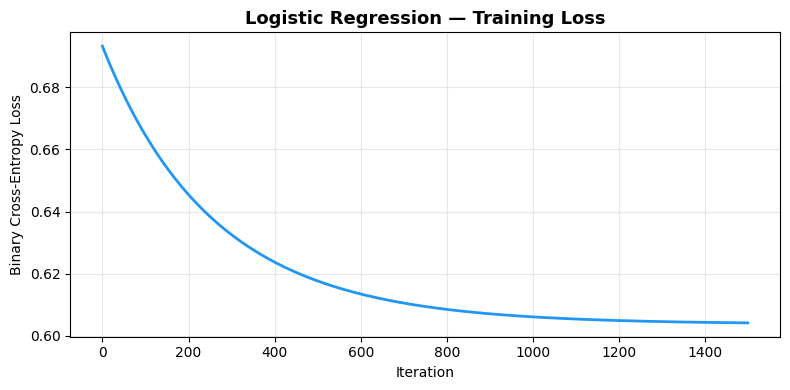

In [12]:
# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(lr_model.loss_history, color='#2196F3', linewidth=2)
plt.title('Logistic Regression — Training Loss', fontsize=13, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lr_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model 2: Multinomial Naive Bayes (from scratch with NumPy)

In [15]:
class MultinomialNaiveBayes:
    """
    Multinomial Naive Bayes implemented from scratch using NumPy.
    Uses Laplace smoothing and log-space computation for numerical stability.
    """
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes = None
        self.log_priors = {}
        self.log_likelihoods = {}

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.classes = np.unique(y)

        for c in self.classes:
            X_c = X[y == c]
            # Log prior: log P(class)
            self.log_priors[c] = np.log(X_c.shape[0] / n_samples)

            # Word counts with Laplace smoothing
            word_counts = np.asarray(X_c.sum(axis=0)).flatten() + self.alpha
            total = word_counts.sum()

            # Log-likelihood: log P(word | class)
            self.log_likelihoods[c] = np.log(word_counts / total)

        print(f'  Class 0 prior: {np.exp(self.log_priors[0]):.3f}')
        print(f'  Class 1 prior: {np.exp(self.log_priors[1]):.3f}')
        return self

    def predict_proba(self, X):
        """Returns probability for each class."""
        log_probs = []
        for c in self.classes:
            log_p = self.log_priors[c] + X.dot(self.log_likelihoods[c])
            if sparse.issparse(log_p):
                log_p = np.asarray(log_p).flatten()
            log_probs.append(log_p)

        log_probs = np.column_stack(log_probs)
        # Numerically stable softmax
        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= threshold).astype(int)

print('✅ MultinomialNaiveBayes class defined')

✅ MultinomialNaiveBayes class defined


In [17]:
# Train Naive Bayes (much faster than LR)
print('Training Multinomial Naive Bayes...')

start = time.time()
nb_model = MultinomialNaiveBayes(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)
elapsed = time.time() - start

print(f'\n✅ Training complete in {elapsed:.1f}s')

Training Multinomial Naive Bayes...
  Class 0 prior: 0.500
  Class 1 prior: 0.500

✅ Training complete in 0.0s


# **Keywork Baseline**

In [18]:
class KeywordBaseline:
    def __init__(self, keywords):
        self.keywords = keywords

    def predict_proba(self, texts):
        probs = []
        for text in texts:
            text = str(text).lower()
            matched = any(keyword in text for keyword in self.keywords)
            probs.append(1.0 if matched else 0.0)
        return np.array(probs)

    def predict(self, texts, threshold=0.5):
        return (self.predict_proba(texts) >= threshold).astype(int)


crisis_keywords = [
    'suicide', 'kill myself', 'end my life', 'die',
    'hopeless', 'worthless', 'self harm', 'hurt myself',
    'no reason to live', 'want to disappear'
]

keyword_model = KeywordBaseline(crisis_keywords)

kw_proba = keyword_model.predict_proba(X_test)
kw_pred = keyword_model.predict(X_test)

kw_metrics = {
    'Model': 'Keyword Baseline',
    'Threshold': 0.5,
    'Recall': recall_score(y_test, kw_pred),
    'Precision': precision_score(y_test, kw_pred),
    'F1-Score': f1_score(y_test, kw_pred),
    'AUC-ROC': roc_auc_score(y_test, kw_proba),
    'Accuracy': (kw_pred == y_test).mean()
}

kw_metrics

{'Model': 'Keyword Baseline',
 'Threshold': 0.5,
 'Recall': 0.3687136393018746,
 'Precision': 0.9089556995644321,
 'F1-Score': 0.5246183089091913,
 'AUC-ROC': np.float64(0.6658750426399388),
 'Accuracy': np.float64(0.6657469282172882)}

## 6. Evaluation & Comparison

In [19]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    proba = model.predict_proba(X_test)
    if proba.ndim > 1:
        proba = proba[:, 1]

    y_pred = (proba >= threshold).astype(int)

    metrics = {
        'Model': model_name,
        'Threshold': threshold,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, proba),
        'Accuracy': accuracy_score(y_test, y_pred)
    }

    print(metrics)
    return metrics, proba, y_pred

# Evaluate both models
kw_metrics, kw_proba, kw_pred = evaluate_model(
    keyword_model,
    X_test,
    y_test,
    'Keyword Baseline'
)

lr_metrics, lr_proba, lr_pred = evaluate_model(
    lr_model,
    X_test_tfidf,
    y_test,
    'Logistic Regression'
)
nb_metrics, nb_proba, nb_pred = evaluate_model(
    nb_model,
    X_test_tfidf,
    y_test,
    'Naive Bayes'
)

{'Model': 'Keyword Baseline', 'Threshold': 0.5, 'Recall': 0.3687136393018746, 'Precision': 0.9089556995644321, 'F1-Score': 0.5246183089091913, 'AUC-ROC': np.float64(0.6658750426399388), 'Accuracy': 0.6657469282172882}
{'Model': 'Logistic Regression', 'Threshold': 0.5, 'Recall': 0.8311570782159018, 'Precision': 0.9037109924093337, 'F1-Score': 0.8659168967607246, 'AUC-ROC': np.float64(0.9440870959289307), 'Accuracy': 0.8712438025436516}
{'Model': 'Naive Bayes', 'Threshold': 0.5, 'Recall': 0.9466063348416289, 'Precision': 0.8840148100450741, 'F1-Score': 0.9142405260857803, 'AUC-ROC': np.float64(0.9729647337443961), 'Accuracy': 0.9111661996119853}


In [21]:
lr_results = []

for lr in [0.01, 0.05, 0.1]:
    for lambda_reg in [0, 0.01, 0.1]:
        model = LogisticRegressionNumPy(
            lr=lr,
            n_iter=1000,
            lambda_reg=lambda_reg
        )

        model.fit(X_train_tfidf, y_train, verbose=False)

        metrics, proba, y_pred = evaluate_model(
            model,
            X_test_tfidf,
            y_test,
            f'LR_lr{lr}_lambda{lambda_reg}'
        )

        lr_results.append(metrics)

lr_tuning_df = pd.DataFrame(lr_results)
lr_tuning_df.to_csv('lr_tuning_results.csv', index=False)
lr_tuning_df

{'Model': 'LR_lr0.01_lambda0', 'Threshold': 0.5, 'Recall': 0.9407455289808231, 'Precision': 0.7877453810623557, 'F1-Score': 0.8574739281575898, 'AUC-ROC': np.float64(0.9408908883637728), 'Accuracy': 0.8435654235826687}
{'Model': 'LR_lr0.01_lambda0.01', 'Threshold': 0.5, 'Recall': 0.9395388924800689, 'Precision': 0.7902138455962305, 'F1-Score': 0.8584309479279456, 'AUC-ROC': np.float64(0.9408745484557686), 'Accuracy': 0.844988143996551}
{'Model': 'LR_lr0.01_lambda0.1', 'Threshold': 0.5, 'Recall': 0.9273001508295626, 'Precision': 0.8082485069300981, 'F1-Score': 0.8636910973749699, 'AUC-ROC': np.float64(0.9407355040355586), 'Accuracy': 0.8535891355895667}
{'Model': 'LR_lr0.05_lambda0', 'Threshold': 0.5, 'Recall': 0.8565826330532212, 'Precision': 0.8839722493996265, 'F1-Score': 0.8700619377995666, 'AUC-ROC': np.float64(0.9419732367325259), 'Accuracy': 0.8720198318603147}
{'Model': 'LR_lr0.05_lambda0.01', 'Threshold': 0.5, 'Recall': 0.85123895712131, 'Precision': 0.8877752808988764, 'F1-Sco

,Model,Threshold,Recall,Precision,F1-Score,AUC-ROC,Accuracy
0,LR_lr0.01_lambda0,0.5,0.940746,0.787745,0.857474,0.940891,0.843565
1,LR_lr0.01_lambda0.01,0.5,0.939539,0.790214,0.858431,0.940875,0.844988
2,LR_lr0.01_lambda0.1,0.5,0.927300,0.808249,0.863691,0.940736,0.853589
3,LR_lr0.05_lambda0,0.5,0.856583,0.883972,0.870062,0.941973,0.872020
4,LR_lr0.05_lambda0.01,0.5,0.851239,0.887775,0.869123,0.941752,0.871761
5,LR_lr0.05_lambda0.1,0.5,0.834260,0.894593,0.863374,0.940681,0.867924
6,LR_lr0.1_lambda0,0.5,0.843180,0.894814,0.868230,0.943059,0.871977
7,LR_lr0.1_lambda0.01,0.5,0.836889,0.896501,0.865670,0.942440,0.870080
8,LR_lr0.1_lambda0.1,0.5,0.832536,0.895476,0.862860,0.940661,0.867622


In [23]:
nb_results = []
nb_models = {}

for alpha in [0.1, 0.5, 1.0, 2.0]:

    model = MultinomialNaiveBayes(alpha=alpha)

    model.fit(X_train_tfidf, y_train)

    metrics, proba, y_pred = evaluate_model(
        model,
        X_test_tfidf,
        y_test,
        f'NB_alpha{alpha}'
    )

    nb_results.append(metrics)

    nb_models[alpha] = model

nb_tuning_df = pd.DataFrame(nb_results)

nb_tuning_df.to_csv(
    'nb_tuning_results.csv',
    index=False
)

nb_tuning_df

  Class 0 prior: 0.500
  Class 1 prior: 0.500
{'Model': 'NB_alpha0.1', 'Threshold': 0.5, 'Recall': 0.9490196078431372, 'Precision': 0.8820796282944805, 'F1-Score': 0.9143260467916381, 'AUC-ROC': np.float64(0.9734010005521758), 'Accuracy': 0.9110368613925415}
  Class 0 prior: 0.500
  Class 1 prior: 0.500
{'Model': 'NB_alpha0.5', 'Threshold': 0.5, 'Recall': 0.9477698771816419, 'Precision': 0.8829693271238156, 'F1-Score': 0.9142227672354665, 'AUC-ROC': np.float64(0.97316877534843), 'Accuracy': 0.9110368613925415}
  Class 0 prior: 0.500
  Class 1 prior: 0.500
{'Model': 'NB_alpha1.0', 'Threshold': 0.5, 'Recall': 0.9466063348416289, 'Precision': 0.8840148100450741, 'F1-Score': 0.9142405260857803, 'AUC-ROC': np.float64(0.9729647337443961), 'Accuracy': 0.9111661996119853}
  Class 0 prior: 0.500
  Class 1 prior: 0.500
{'Model': 'NB_alpha2.0', 'Threshold': 0.5, 'Recall': 0.9443223443223443, 'Precision': 0.8854095114954139, 'F1-Score': 0.9139175042749301, 'AUC-ROC': np.float64(0.9726409968775088)

,Model,Threshold,Recall,Precision,F1-Score,AUC-ROC,Accuracy
0,NB_alpha0.1,0.5,0.949020,0.882080,0.914326,0.973401,0.911037
1,NB_alpha0.5,0.5,0.947770,0.882969,0.914223,0.973169,0.911037
2,NB_alpha1.0,0.5,0.946606,0.884015,0.914241,0.972965,0.911166
3,NB_alpha2.0,0.5,0.944322,0.885410,0.913918,0.972641,0.911015


In [24]:
summary = pd.DataFrame([kw_metrics, lr_metrics, nb_metrics])
summary.to_csv('final_model_comparison.csv', index=False)
summary

,Model,Threshold,Recall,Precision,F1-Score,AUC-ROC,Accuracy
0,Keyword Baseline,0.5,0.368714,0.908956,0.524618,0.665875,0.665747
1,Logistic Regression,0.5,0.831157,0.903711,0.865917,0.944087,0.871244
2,Naive Bayes,0.5,0.946606,0.884015,0.914241,0.972965,0.911166


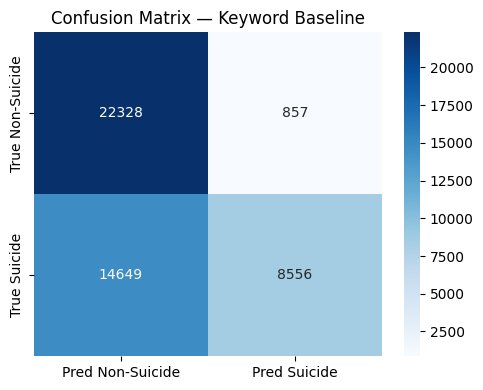

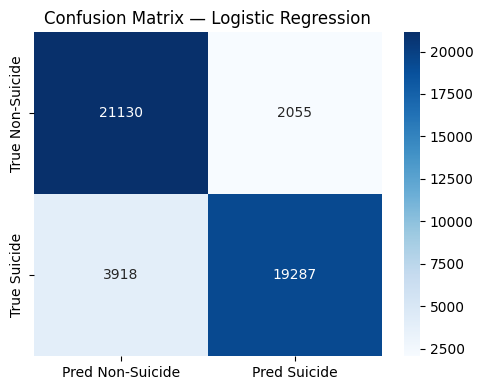

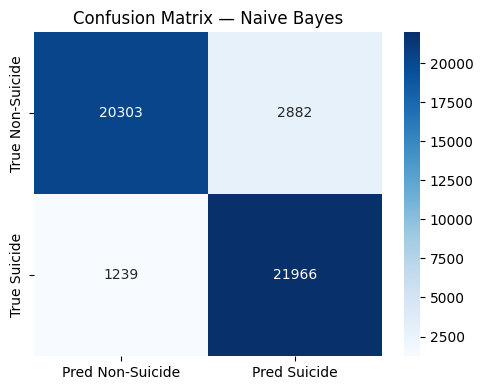

In [25]:
models_preds = {
    'Keyword Baseline': kw_pred,
    'Logistic Regression': lr_pred,
    'Naive Bayes': nb_pred
}

for name, pred in models_preds.items():
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred Non-Suicide', 'Pred Suicide'],
        yticklabels=['True Non-Suicide', 'True Suicide']
    )
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_").lower()}.png', dpi=150)
    plt.show()

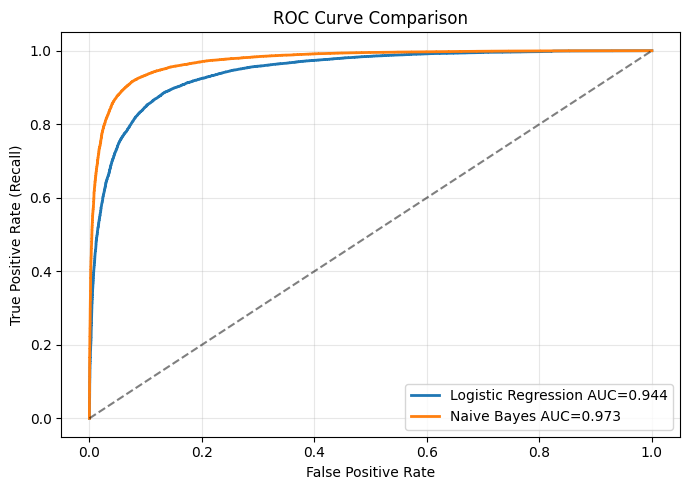

In [26]:
# ROC Curve Comparison

plt.figure(figsize=(7, 5))

for proba, label in [
    (lr_proba, f'Logistic Regression AUC={lr_metrics["AUC-ROC"]:.3f}'),
    (nb_proba, f'Naive Bayes AUC={nb_metrics["AUC-ROC"]:.3f}')
]:

    fpr, tpr, _ = roc_curve(y_test, proba)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=label
    )

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'roc_curve_comparison.png',
    dpi=150
)

plt.show()

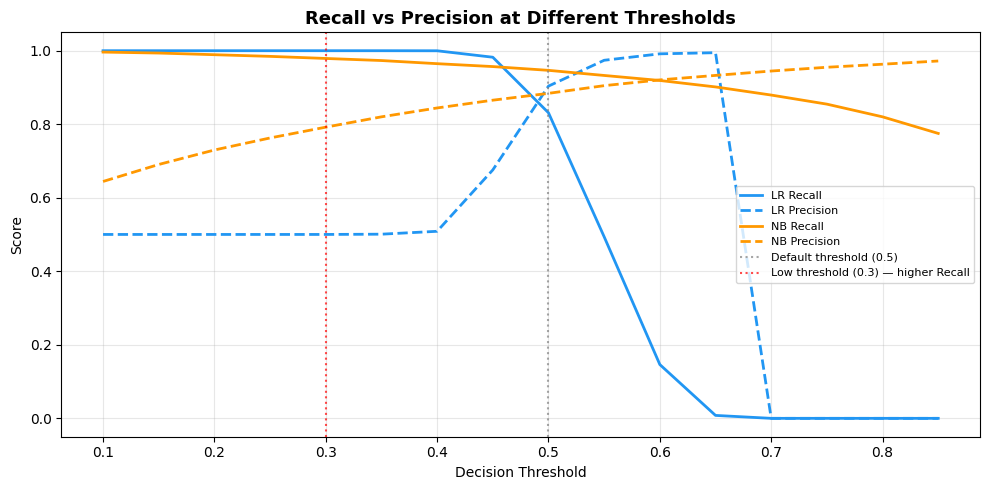

💡 In clinical settings, lower threshold → higher Recall (fewer missed cases)


In [27]:
# Threshold analysis — clinical setting favors high Recall
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    for proba, name in [(lr_proba, 'LR'), (nb_proba, 'NB')]:
        y_pred = (proba >= t).astype(int)
        results.append({
            'threshold': t,
            'model': name,
            'recall': recall_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred)
        })

thresh_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
for model, color in [('LR', '#2196F3'), ('NB', '#FF9800')]:
    sub = thresh_df[thresh_df['model'] == model]
    ax.plot(sub['threshold'], sub['recall'], color=color, linewidth=2, linestyle='-', label=f'{model} Recall')
    ax.plot(sub['threshold'], sub['precision'], color=color, linewidth=2, linestyle='--', label=f'{model} Precision')

ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default threshold (0.5)')
ax.axvline(x=0.3, color='red', linestyle=':', alpha=0.7, label='Low threshold (0.3) — higher Recall')
ax.set_title('Recall vs Precision at Different Thresholds', fontsize=13, fontweight='bold')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.legend(loc='center right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 In clinical settings, lower threshold → higher Recall (fewer missed cases)')

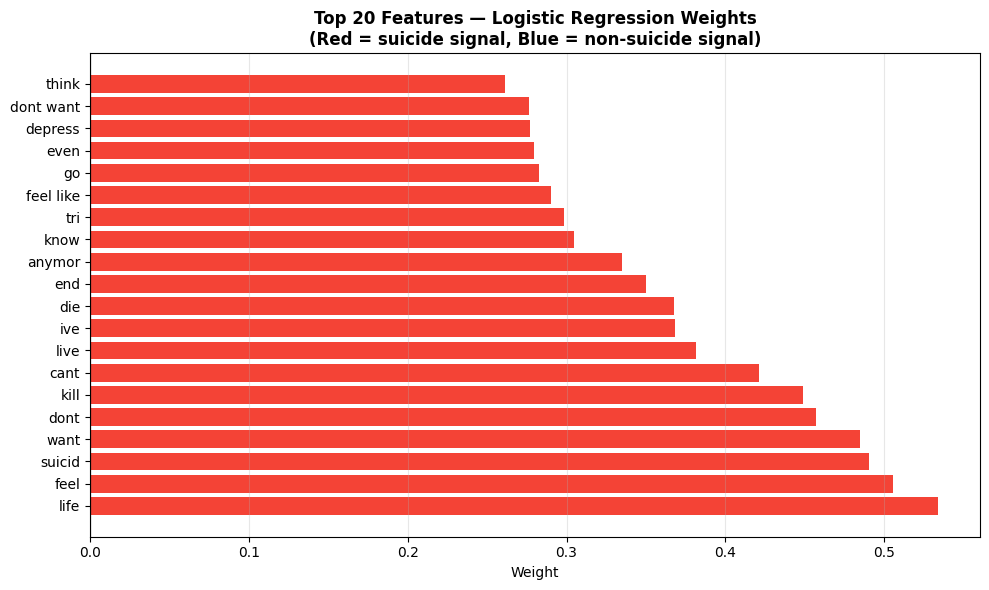

In [28]:
# Top contributing features (for Streamlit interpretability panel)
feature_names = np.array(tfidf.get_feature_names_out())
top_n = 20

# Logistic Regression weights
top_idx = np.argsort(np.abs(lr_model.weights))[-top_n:][::-1]
top_features = pd.DataFrame({
    'feature': feature_names[top_idx],
    'weight': lr_model.weights[top_idx]
})

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#F44336' if w > 0 else '#2196F3' for w in top_features['weight']]
ax.barh(top_features['feature'], top_features['weight'], color=colors)
ax.set_title('Top 20 Features — Logistic Regression Weights\n(Red = suicide signal, Blue = non-suicide signal)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Weight')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('top_features.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================
# Save Final Artifacts
# ============================

In [29]:
import os
import pickle
import json
import numpy as np

SAVE_DIR = './final_artifacts/'
os.makedirs(SAVE_DIR, exist_ok=True)

In [30]:
with open(f'{SAVE_DIR}best_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open(f'{SAVE_DIR}tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

np.save(f'{SAVE_DIR}feature_names.npy', feature_names)

In [31]:
summary.to_csv(f'{SAVE_DIR}final_model_comparison.csv', index=False)

In [32]:
metadata = {
    "best_model": "Multinomial Naive Bayes",
    "alpha": 1.0,
    "default_threshold": 0.5,
    "recommended_screening_threshold": 0.3,
    "primary_metric": "Recall",
    "reason_for_selection": "Naive Bayes achieved the strongest overall performance, especially recall, F1-score, and AUC-ROC."
}

with open(f'{SAVE_DIR}model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

In [33]:
!zip -r final_artifacts.zip final_artifacts *.png *.csv

  adding: final_artifacts/ (stored 0%)
  adding: final_artifacts/feature_names.npy (deflated 67%)
  adding: final_artifacts/tfidf_vectorizer.pkl (deflated 69%)
  adding: final_artifacts/final_model_comparison.csv (deflated 33%)
  adding: final_artifacts/model_metadata.json (deflated 32%)
  adding: final_artifacts/best_model.pkl (deflated 8%)
  adding: confusion_matrix_keyword_baseline.png (deflated 13%)
  adding: confusion_matrix_logistic_regression.png (deflated 13%)
  adding: confusion_matrix_naive_bayes.png (deflated 12%)
  adding: eda_distribution.png (deflated 20%)
  adding: lr_loss_curve.png (deflated 11%)
  adding: roc_curve_comparison.png (deflated 11%)
  adding: threshold_analysis.png (deflated 6%)
  adding: top_features.png (deflated 22%)
  adding: clean_data.csv (deflated 64%)
  adding: final_model_comparison.csv (deflated 33%)
  adding: lr_tuning_results.csv (deflated 52%)
  adding: nb_tuning_results.csv (deflated 45%)
